# 5. Optimización de Modelos

**Punto de partida:** los artefactos guardados por `4_Modeling.ipynb` en `../models/` (`data.pkl`, `modelos_entrenados.pkl`, `metrics.pkl`, `scaler.pkl`).

**Objetivo del notebook:** los modelos entrenados en el módulo anterior usaron hiperparámetros por defecto. Aquí se busca sistemáticamente la mejor combinación de hiperparámetros para cada algoritmo mediante **Grid Search**, y se compara el desempeño antes y después de la optimización.

A diferencia de los parámetros que un modelo aprende durante el entrenamiento (por ejemplo, los coeficientes de una regresión), los **hiperparámetros** se definen *antes* de entrenar y controlan cómo aprende el modelo (profundidad máxima de un árbol, número de árboles en un bosque, fuerza de regularización, etc.). Ajustarlos mal puede llevar a subajuste o sobreajuste, incluso con el mismo algoritmo y los mismos datos.

In [1]:
# Plomería del entorno (no es parte del análisis): se fija la versión de
# scikit-learn. Los modelos serializados en ../models/*.pkl se guardaron con la
# 1.9.0, y joblib.load() advierte o falla al abrirlos con una versión distinta.
# %pip install -q scikit-learn==1.9.0

# import sklearn
# print("scikit-learn:", sklearn.__version__)
# if sklearn.__version__ != "1.9.0":
#     print("Versión distinta a la esperada (1.9.0).")
#     print("En Colab: menú Entorno de ejecución > Reiniciar sesión, y ejecuta de nuevo esta celda.")

In [2]:
import joblib
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## cargar librerias de visualizacion
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, confusion_matrix


Se reutilizan las mismas librerías del módulo anterior: `pandas`/`seaborn`/`matplotlib` para datos y visualización, y de `scikit-learn` se importan de una vez `GridSearchCV` (búsqueda de hiperparámetros) y las métricas de clasificación que se usarán a lo largo del notebook.

## Cargar:
* datos
* modelos
* metricas

### Parámetros del experimento

Se mantienen `target` y `num_feat` iguales al módulo anterior. El cambio importante es la métrica de optimización: aquí se prioriza **`recall`** en lugar de `roc_auc`.

**¿Por qué recall?** En el contexto de churn, un **falso negativo** (un cliente que sí va a abandonar y el modelo no lo detecta) tiene un costo de negocio mayor que un **falso positivo** (contactar a un cliente que en realidad iba a quedarse). Optimizar directamente por `recall` orienta la búsqueda de hiperparámetros hacia modelos que dejen escapar menos clientes en riesgo, aunque eso implique más falsas alarmas.

In [3]:
target = "churn"
num_feat = ["tenure", "monthlycharges"]
clases_map = {0: "No Churn", 1: "Churn"}
alias_model = {"LogisticRegression":"LS", "DecisionTree":"DT", "RandomForest":"RF"}

# metric = "roc_auc"
metric = "recall"

Se cargan los artefactos persistidos en `4_Modeling.ipynb`. Como `data.pkl` y `metrics.pkl` se guardaron como diccionarios, se usa `.values()` para desempacarlos directamente en variables individuales.

> **Nota:** `.values()` desempaca en el mismo orden en que se guardaron las llaves del diccionario. Funciona porque ese orden es estable (Python preserva el orden de inserción), pero es una dependencia implícita: si en `4_Modeling.ipynb` cambiara el orden en que se arma el diccionario antes de `joblib.dump(...)`, esta celda asignaría las variables equivocadas sin lanzar ningún error. Una alternativa más explícita y a prueba de reordenamientos sería acceder por llave, por ejemplo `data = joblib.load(...); X_train = data["X_train"]`.

In [4]:
X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled = joblib.load("../models/data.pkl").values()
train_metrics_default, test_metrics_default, c_matrix_default = joblib.load("../models/metrics.pkl").values()
models = joblib.load("../models/modelos_entrenados.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Datos, Modelo, Scaler y Metricas cargados.")


Datos, Modelo, Scaler y Metricas cargados.


Verificación rápida: `X_train` ya debería excluir la variable objetivo (`feat` se calculó así en `4_Modeling.ipynb`), por lo que esta lista debería coincidir exactamente con todas las columnas de `X_train`. Sirve como chequeo de consistencia antes de continuar.

In [5]:
## Separación de variables predictoras y variable objetivo
feat    = [col for col in X_train.columns if col != target]
print("El numero de variables predictoras es:", len(feat))

El numero de variables predictoras es: 24


## Ajuste de hiperparametros

### ¿Cómo se define el espacio de búsqueda?

Para cada modelo se define una rejilla (`grid`) de valores candidatos por hiperparámetro. `GridSearchCV` probará **todas las combinaciones posibles** dentro de esa rejilla:

- **Regresión Logística**: fuerza de regularización (`C`), y si se compensa o no el desbalance de clases   (`class_weight`).
- **Decision Tree**: profundidad máxima y tamaños mínimos de partición/hoja, para controlar el sobreajuste   característico de los árboles sin restricciones.
- **Random Forest**: número de árboles del ensamble además de los mismos controles de profundidad y   tamaño mínimo.

El tamaño de la rejilla importa: cada hiperparámetro adicional multiplica el número de combinaciones a evaluar (y cada combinación se entrena `cv` veces).

In [6]:
param_grids = {
    "LogisticRegression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"],
        "max_iter": [1000]
    },

    "DecisionTree": {
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },

    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt"]
    }
}
param_grids

{'LogisticRegression': {'C': [0.1, 1, 10],
  'solver': ['lbfgs'],
  'class_weight': [None, 'balanced'],
  'max_iter': [1000]},
 'DecisionTree': {'max_depth': [5, 10, 20, None],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 5]},
 'RandomForest': {'n_estimators': [100, 200],
  'max_depth': [10, 20, None],
  'min_samples_split': [2, 5],
  'min_samples_leaf': [1, 2],
  'max_features': ['sqrt']}}

### Grid Search

`GridSearchCV` entrena y evalúa **cada combinación de la rejilla** con validación cruzada de 5 folds (`cv=5`), usando `recall` como criterio de selección (`scoring=metric`). Al finalizar, conserva automáticamente el mejor estimador encontrado (`best_estimator_`) ya reentrenado sobre todo `X_train`.

Como en el módulo anterior, la Regresión Logística usa las variables escaladas (`X_train_scaled`) y los modelos basados en árboles usan `X_train` sin escalar, ya que no lo necesitan.

In [7]:
grid_search = dict()
train_predictions = dict()
modelos_optimizados = dict()

for name,model in models.items():
    print(f"*********** Buscando hiperparametros para {name} *************")
    grid_search[name] = GridSearchCV(
                            estimator=model["model"],
                            param_grid=param_grids[name],
                            scoring=metric,
                            cv=5,
                            n_jobs=-1,
                            verbose=1
                        )
    X_ = X_train_scaled if name=="LogisticRegression" else X_train
    grid_search[name].fit(X_, y_train)
    modelos_optimizados[name] = grid_search[name].best_estimator_
    train_predictions[name] = {
                                "pred": modelos_optimizados[name].predict(X_)
                                , "prob": modelos_optimizados[name].predict_proba(X_)[:, 1]
                            }
print("")
grid_search

*********** Buscando hiperparametros para LogisticRegression *************
Fitting 5 folds for each of 6 candidates, totalling 30 fits
*********** Buscando hiperparametros para DecisionTree *************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
*********** Buscando hiperparametros para RandomForest *************
Fitting 5 folds for each of 24 candidates, totalling 120 fits



{'LogisticRegression': GridSearchCV(cv=5,
              estimator=LogisticRegression(max_iter=1000, random_state=123),
              n_jobs=-1,
              param_grid={'C': [0.1, 1, 10], 'class_weight': [None, 'balanced'],
                          'max_iter': [1000], 'solver': ['lbfgs']},
              scoring='recall', verbose=1),
 'DecisionTree': GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=123),
              n_jobs=-1,
              param_grid={'max_depth': [5, 10, 20, None],
                          'min_samples_leaf': [1, 2, 5],
                          'min_samples_split': [2, 5, 10]},
              scoring='recall', verbose=1),
 'RandomForest': GridSearchCV(cv=5,
              estimator=RandomForestClassifier(n_estimators=200,
                                               random_state=123),
              n_jobs=-1,
              param_grid={'max_depth': [10, 20, None], 'max_features': ['sqrt'],
                          'min_samples_leaf': [1, 2],
    

Se muestran los mejores hiperparámetros encontrados para cada modelo, junto con el mejor `recall` promedio obtenido en la validación cruzada interna de `GridSearchCV` (`best_score_`).

In [8]:
print("Mejores hiperparametros encontrados:")
dict((name, {
                metric: model.best_score_
                , "best_params": dict((a,b) for a,b in model.best_params_.items() if b!=None)
        }) for name, model in grid_search.items())

Mejores hiperparametros encontrados:


{'LogisticRegression': {'recall': np.float64(0.7919732441471572),
  'best_params': {'C': 1,
   'class_weight': 'balanced',
   'max_iter': 1000,
   'solver': 'lbfgs'}},
 'DecisionTree': {'recall': np.float64(0.5464882943143812),
  'best_params': {'max_depth': 5,
   'min_samples_leaf': 1,
   'min_samples_split': 2}},
 'RandomForest': {'recall': np.float64(0.5190635451505017),
  'best_params': {'max_depth': 10,
   'max_features': 'sqrt',
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'n_estimators': 100}}}

In [9]:
def get_metrics(y_real, predictions):
    metrics = []
    for name, pred in predictions.items():
        # print(y_real.shape, dict((k,len(v)) for k,v in pred.items()))
        metrics.append({
            "model": name,
            "accuracy": accuracy_score(y_real, pred["pred"]),
            "precision": precision_score(y_real, pred["pred"]),
            "recall": recall_score(y_real, pred["pred"]),
            "f1": f1_score(y_real, pred["pred"]),
            "roc_auc": roc_auc_score(y_real, pred["prob"])
        })
    metrics = pd.DataFrame(metrics).set_index("model")
    return metrics

In [10]:
train_metrics = get_metrics(y_train, train_predictions)
train_metrics

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.751864,0.521188,0.797993,0.630550,0.846082
DecisionTree,0.798367,0.618953,0.624749,0.621838,0.853404
RandomForest,0.858360,0.784490,0.642809,0.706618,0.934445


### Interpretación

Se espera que la búsqueda de hiperparámetros aporte una mejora — o al menos igualdad — frente a los valores por defecto usados en `4_Modeling.ipynb`, ya que `GridSearchCV` explora explícitamente el espacio de configuraciones en vez de depender de los valores por defecto de `scikit-learn`. La magnitud de la mejora no es igual para todos los modelos: algoritmos más sensibles a sus hiperparámetros (como los basados en árboles) suelen beneficiarse más que modelos con pocos hiperparámetros relevantes (como la Regresión Logística, donde `C` es prácticamente el único que se ajusta).

Como referencia, se recuperan las métricas de `train` y `test` calculadas en `4_Modeling.ipynb` con los modelos por defecto (antes de esta optimización), para poder comparar contra ellas.

In [11]:
train_metrics_default

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.804579,0.658106,0.548495,0.598322,0.846351
DecisionTree,0.997515,0.999326,0.991304,0.995299,0.999984
RandomForest,0.997515,0.995318,0.995318,0.995318,0.999956


### Tabla comparativa: antes vs. después de la optimización

Se arma una tabla con el `recall` de cada modelo en tres escenarios: `train` (valores por defecto, sobre datos de entrenamiento), `test` (valores por defecto, sobre datos nuevos) y `GridSearch` (mejor score de validación cruzada tras la búsqueda de hiperparámetros).

> La columna `GridSearch` se arma en el mismo orden en que se recorrió el diccionario `models` al entrenar los `grid_search`. Como `train_metrics`, `test_metrics` y `models` se construyeron con las mismas llaves en `4_Modeling.ipynb`, el orden coincide — pero al ser una alineación **posicional** y no por nombre de modelo, es sensible a que ese orden se mantenga igual en todos los notebooks.

In [12]:
cols_metrics = [l for lst in [[c+"_D", c+"_GS"] for c in train_metrics] for l in lst]
pd.concat([train_metrics_default.add_suffix("_D"), train_metrics.add_suffix("_GS")], axis=1)[cols_metrics]

,accuracy_D,accuracy_GS,precision_D,precision_GS,recall_D,recall_GS,f1_D,f1_GS,roc_auc_D,roc_auc_GS
model,,,,,,,,,,
LogisticRegression,0.804579,0.751864,0.658106,0.521188,0.548495,0.797993,0.598322,0.630550,0.846351,0.846082
DecisionTree,0.997515,0.798367,0.999326,0.618953,0.991304,0.624749,0.995299,0.621838,0.999984,0.853404
RandomForest,0.997515,0.858360,0.995318,0.784490,0.995318,0.642809,0.995318,0.706618,0.999956,0.934445


In [13]:
resultados = pd.concat([train_metrics_default[[metric]], train_metrics[[metric]]], axis=1)
resultados.columns = [f"{metric} Default",f"{metric} Grid Search"]
# resultados[f"{metric.upper()} (GridSearch)"] = list(model.best_score_ for name, model in grid_search.items())
resultados

,recall Default,recall Grid Search
model,,
LogisticRegression,0.548495,0.797993
DecisionTree,0.991304,0.624749
RandomForest,0.995318,0.642809


**Cómo leer esta tabla:** para `DecisionTree` y `RandomForest`, el recall en `train` **baja** después del Grid Search (por ejemplo, el árbol pasa de 0.99 a ~0.62). Eso no es un fracaso de la optimización — es la señal contraria: los modelos por defecto de `4_Modeling.ipynb` estaban memorizando el conjunto de entrenamiento (sobreajuste extremo, visible en un recall casi perfecto en `train`); el Grid Search encontró hiperparámetros más regularizados, que generalizan mejor aunque "aprendan" menos el pasado de memoria. La comparación que realmente importa es la de `test`, un poco más abajo en este notebook — ahí el recall optimizado sí mejora frente a los modelos por defecto en los tres algoritmos.

## Evaluar desempeño

### Desempeño de los modelos optimizados sobre `test`

Se calcula la métrica de optimización (`recall`, en este caso) para cada modelo ya afinado, evaluado sobre el conjunto de `test` — el chequeo real de qué tanto generaliza cada modelo optimizado a datos nuevos. El bloque `if/elif` permite reutilizar esta celda con otra métrica de optimización simplemente cambiando `metric` en la celda de parámetros; si se usa una métrica no contemplada, la excepción avisa explícitamente en vez de fallar en silencio.

In [14]:
test_predictions = dict()

for name, model in modelos_optimizados.items():
    X_ =  X_test_scaled if name=="LogisticRegression" else X_test
    y_prob = model.predict_proba(X_)[:, 1]
    y_pred = model.predict(X_)
    test_predictions[name] = {"pred":y_pred, "prob":y_prob}

test_predictions

{'LogisticRegression': {'pred': array([0, 0, 0, ..., 0, 0, 1], shape=(1409,)),
  'prob': array([0.02424084, 0.33149128, 0.08884953, ..., 0.01469215, 0.33552327,
         0.67240345], shape=(1409,))},
 'DecisionTree': {'pred': array([0, 0, 0, ..., 0, 0, 0], shape=(1409,)),
  'prob': array([0.00542299, 0.376     , 0.03106796, ..., 0.00542299, 0.0852459 ,
         0.4195122 ], shape=(1409,))},
 'RandomForest': {'pred': array([0, 0, 0, ..., 0, 0, 0], shape=(1409,)),
  'prob': array([0.00469101, 0.26287603, 0.06687772, ..., 0.0256884 , 0.11061441,
         0.44557997], shape=(1409,))}}

### Glosario de métricas de clasificación

Con el modelo ya optimizado, se calcula el conjunto completo de métricas — no solo `recall` — para tener una vista integral del desempeño y poder contrastar el costo/beneficio de haber optimizado por `recall` en lugar de otra métrica.

* ***Accuracy***: Porcentaje total de aciertos
* ***Precision***: De los clientes predichos como churn, cuántos realmente abandonan
* ***Recall***: De los clientes que abandonan, cuántos detecta el modelo
* ***F1***: Balance entre precision y recall
* ***ROC-AUC***: Capacidad general de discriminación

In [15]:
test_metrics = get_metrics(y_test, test_predictions)
test_metrics.style.format('{:.5f}')

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.75869,0.53058,0.78877,0.63441,0.84255
DecisionTree,0.79347,0.60892,0.62032,0.61457,0.82878
RandomForest,0.79915,0.65424,0.51604,0.57698,0.83832


Se selecciona el modelo ganador ordenando por la métrica objetivo (`recall`) sobre `test`, de forma consistente con el criterio de optimización usado en la búsqueda de hiperparámetros.

In [16]:
best_model_name = test_metrics.sort_values(metric, ascending=False).iloc[0].name
print(f"Mejor modelo según {metric.upper()}:", best_model_name)

Mejor modelo según RECALL: LogisticRegression


## Matriz de confusión

Al haber optimizado explícitamente por `recall`, se espera ver en la matriz de confusión **menos falsos negativos** (`fn`, clientes que abandonan y el modelo no detecta) frente a lo observado en `4_Modeling.ipynb` con los modelos por defecto — posiblemente a cambio de más falsos positivos (`fp`). Las tasas `tpr` (= recall) y `fnr` son las que directamente reflejan ese trade-off.

In [17]:
c_matrix = dict()

for name, pred in test_predictions.items():
    c_matrix[name] = {"confusion_matrix": confusion_matrix(y_test, pred["pred"])}
    tn, fp, fn, tp = c_matrix[name]["confusion_matrix"].ravel()
    c_matrix[name].update({"tn":tn, "fp":fp, "fn":fn, "tp":tp})
    total = int(tp + tn + fp + fn)
    c_matrix[name].update({
                        "tpr": (tp / (tp + fn) if (tp + fn) > 0 else 0)
                        , "tnr": (tn / (tn + fp) if (tn + fp) > 0 else 0)
                        , "fpr": (fp / (fp + tn) if (fp + tn) > 0 else 0)
                        , "fnr": (fn / (fn + tp) if (fn + tp) > 0 else 0)
                })
print("Conteos y Ratios:")
pd.DataFrame(c_matrix).iloc[1:].T

Conteos y Ratios:


,tn,fp,fn,tp,tpr,tnr,fpr,fnr
LogisticRegression,774,261,79,295,0.78877,0.747826,0.252174,0.21123
DecisionTree,886,149,142,232,0.620321,0.856039,0.143961,0.379679
RandomForest,933,102,181,193,0.516043,0.901449,0.098551,0.483957


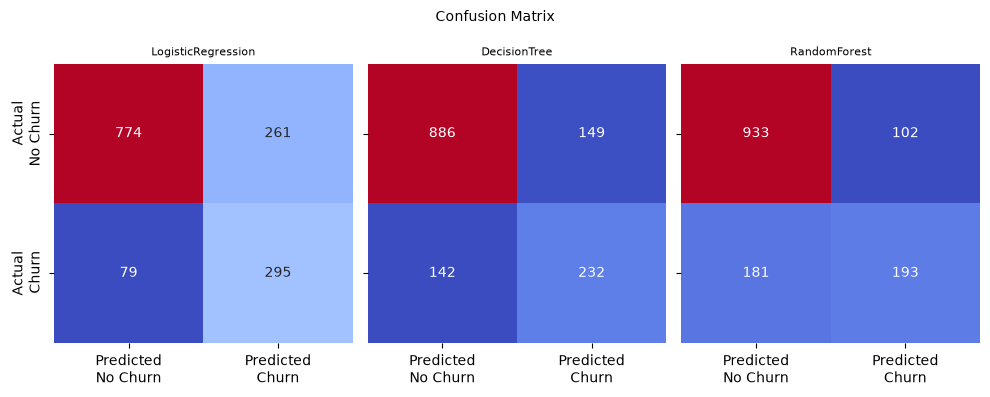

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=len(models), figsize=(10, 4))
axes = axes.flatten()
for i,name in enumerate(c_matrix):
    sns.heatmap(
                c_matrix[name]["confusion_matrix"]
                , annot=True, fmt="d", cmap="coolwarm", cbar=False
                # , xticklabels=["Predicted\nNo Churn", "Predicted\nChurn"], yticklabels=["Actual\nNo Churn", "Actual\nChurn"]
                , ax=axes[i]
            )
    if i==0:
        axes[i].set_yticklabels(["Actual\nNo Churn", "Actual\nChurn"])
    else:
        axes[i].set_yticklabels("")
    axes[i].set_xticklabels(["Predicted\nNo Churn", "Predicted\nChurn"])
    axes[i].set_title(f"{name}", size=8)
fig.suptitle(f"Confusion Matrix", size=10)
plt.tight_layout()
plt.show()

## Curva ROC-AUC

La curva ROC muestra, para cada posible umbral de decisión, la relación entre la **Tasa de Verdaderos Positivos** (Recall) y la **Tasa de Falsos Positivos**. Cuanto más se acerque la curva a la esquina superior izquierda, mejor discrimina el modelo entre clases. El área bajo la curva (AUC) resume ese desempeño en un solo número: 0.5 equivale a una predicción aleatoria y 1.0 a una separación perfecta.

> Aunque la optimización de esta sección se hizo sobre `recall` y no sobre `roc_auc`, la curva ROC sigue siendo útil como referencia general de la capacidad de discriminación de cada modelo, independiente del umbral de decisión específico.

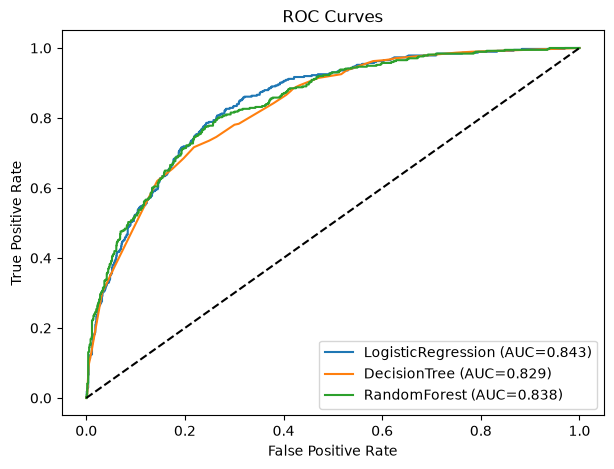

In [19]:
plt.figure(figsize=(7,5))

for name, pred in test_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, pred["prob"])
    auc = roc_auc_score(y_test, pred["prob"])

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

## Guardar datos con resultados basados en la optimización

Se retoma el Excel ya exportado en `4_Modeling.ipynb` (predicciones de los 3 modelos por defecto) y se le agregan, como columnas adicionales, las predicciones de los 3 modelos **ya optimizados** — prefijadas con `alias_model` y con el sufijo `_best` (por ejemplo `RF_pred_best`) para distinguirlas de las predicciones por defecto que ya traía el archivo, sin sobrescribirlas.

Se carga el Excel existente indexado por `customerID`, para poder unir las nuevas columnas alineando por cliente.

In [20]:
## cargar Resultados
data_ = pd.read_excel("../output/Telco-Customer-Churn_Resultados.xlsx").set_index("customerID")
print(f"{data_.shape=}")
# data_

data_.shape=(7043, 32)


In [21]:
data_ = pd.concat([
            data_
            , pd.concat([
                    pd.concat(
                                list(pd.DataFrame(train_predictions[name]).add_prefix(alias+"_").add_suffix("_best") for name,alias in alias_model.items())
                                , axis=1
                            ).set_index(X_train.index)
                    , pd.concat(
                                list(pd.DataFrame(test_predictions[name]).add_prefix(alias+"_").add_suffix("_best") for name,alias in alias_model.items())
                                , axis=1
                            ).set_index(X_test.index)
                    ]
                , axis=0
            )
            ]
        , axis=1)

print(f"{data_.shape=}")
data_

data_.shape=(7043, 38)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn,split,LS_pred,LS_prob,DT_pred,DT_prob,RF_pred,RF_prob,LS_pred_best,LS_prob_best,DT_pred_best,DT_prob_best,RF_pred_best,RF_prob_best
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5605-XNWEN,0,1,1,0,72,1,1,0,0,0,0,0,0,1,25.00,0,0,0,0,1,1,0,0,0,0,train,0,0.012131,0,0.0,0,0.000,0,0.030233,0,0.052632,0,0.000714
7409-KIUTL,1,1,0,1,1,1,0,0,0,0,0,0,0,1,71.00,0,1,1,0,0,0,0,1,0,1,train,1,0.703638,1,1.0,1,0.950,1,0.864001,1,0.827160,1,0.849171
0971-QIFJK,1,0,1,0,69,1,1,0,0,0,0,0,0,0,24.25,0,0,0,0,1,1,0,0,0,0,train,0,0.007739,0,0.0,0,0.000,0,0.019476,0,0.005423,0,0.003046
2675-DHUTR,0,1,1,0,58,1,1,0,1,0,0,1,1,1,98.90,0,1,1,0,0,0,0,1,0,0,train,0,0.474156,0,0.0,0,0.215,1,0.725741,0,0.278689,0,0.486244
5201-FRKKS,0,0,0,0,25,1,0,1,0,0,0,0,0,0,74.30,0,1,1,0,0,1,0,0,0,0,train,0,0.282805,0,0.0,0,0.060,1,0.529927,0,0.271493,0,0.281076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7851-WZEKY,1,0,0,0,2,1,1,0,0,0,0,1,1,1,95.15,0,1,1,0,0,0,0,1,0,1,test,1,0.837210,1,1.0,1,0.975,1,0.932264,1,0.715596,1,0.842782
0616-ATFGB,0,1,1,0,1,0,0,0,0,0,0,0,0,0,25.05,1,0,1,0,0,0,0,1,0,1,test,1,0.549594,1,1.0,1,0.685,1,0.762884,1,0.814815,1,0.617386
7169-YWAMK,0,0,1,1,72,1,0,1,1,0,1,1,0,0,68.40,1,0,0,0,1,1,0,0,0,0,test,0,0.005099,0,0.0,0,0.100,0,0.014692,0,0.005423,0,0.025688


## Guardar modelo con ajuste de hiperparámetros

Se persisten los artefactos de esta optimización con nombres de archivo distintos a los de `4_Modeling.ipynb` (`modelos_optimizados.pkl`, `metrics_modelos_optimizados.pkl`), para no sobrescribir los modelos por defecto — ambas versiones quedan disponibles en `../models/` para comparar.

Se sobrescribe el Excel de resultados con las columnas de los modelos optimizados ya incorporadas.

In [22]:
fName = "../output/Telco-Customer-Churn_Resultados.xlsx"
data_.reset_index().to_excel(fName, index=False)
print(fName)

../output/Telco-Customer-Churn_Resultados.xlsx


Se guardan los modelos ya afinados por `GridSearchCV` (`modelos_optimizados`) — **no** el diccionario `models` original, que sigue conteniendo los modelos con hiperparámetros por defecto cargados desde `4_Modeling.ipynb`.

In [23]:
joblib.dump(modelos_optimizados, f"../models/modelos_optimizados.pkl")
joblib.dump({"train_metrics": train_metrics, "test_metrics":test_metrics, "confusion_matrix": c_matrix}, 
            f"../models/metrics_modelos_optimizados.pkl"
        )

print("Guardado de modelos actualizados.")

Guardado de modelos actualizados.
